# Notebook 1 — Classical RSA: Alice sends a message to Bob

This notebook walks the researcher through the classical RSA cryptosystem step by step.

**Scenario**
- Bob generates an RSA key pair and publishes the **public key** `(N, e)`.
- Alice uses Bob's public key to encrypt a secret message.
- Bob uses his **private key** `d` to decrypt it.
- Eve, the adversary, will appear in Notebooks 2 and 3.

**Why `N = 15` is used everywhere.** All three notebooks (RSA, classical attack, quantum attack) use the *same* modulus so that the demonstration stays uniform. `N = 15` is the largest semiprime for which Shor's algorithm reliably executes on today's noisy 156‑qubit hardware — that point is revisited in Notebook 3. The trade-off is that an RSA modulus this small can only hold a single integer plaintext `0 < m < 15`, so the 'message' in this demonstration is literally the integer `m = 8` rather than an ASCII string. Mathematically the operations are identical to real RSA; only the magnitudes change.

**Canonical demo values used by all three notebooks**

| symbol | value |
|--------|-------|
| `p`        | `3` |
| `q`        | `5` |
| `N = p·q`  | `15` (4 bits) |
| `φ(N)`     | `8` |
| `e`        | `3` |
| `d`        | `3` |
| plaintext  | `m = 8` |
| ciphertext | `c = 2` (= `8³ mod 15`) |

Notebooks 2 and 3 attack the same `(N=15, e=3, c=2)` and the researcher should observe the same `m = 8` being recovered there.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from sympy import isprime, gcd, mod_inverse

%matplotlib inline

## 1. Key generation (performed by Bob)

Bob picks two prime numbers `p` and `q` and computes:

$$N = p\,q, \qquad \varphi(N) = (p-1)(q-1)$$

Bob then picks a public exponent `e` that is coprime to `φ(N)` and computes the modular inverse:

$$d \equiv e^{-1} \pmod{\varphi(N)}$$

- **Public key:** `(N, e)` — published openly, visible to Alice and to Eve.
- **Private key:** `d` — kept secret by Bob.

The researcher pins `p = 3`, `q = 5` so that all three notebooks agree on the same `N`, the same `e`, the same ciphertext `c`, and the same plaintext.

In [2]:
# Canonical demo primes (kept fixed across all three notebooks).
p = 3
q = 5

assert isprime(p) and isprime(q) and p != q

N   = p * q
phi = (p - 1) * (q - 1)
e   = 3
assert gcd(e, phi) == 1, 'e must be coprime to phi(N)'
d   = int(mod_inverse(e, phi))

print(f'p          = {p}')
print(f'q          = {q}')
print(f'N = p*q    = {N}    ({N.bit_length()} bits)')
print(f'phi(N)     = {phi}')
print(f'e (public) = {e}')
print(f'd (secret) = {d}')
print()
print(f'Textbook Shor qubit budget        (3 * n) ~ {3 * N.bit_length()}')
print(f"Beauregard's compiled Shor budget (2n+3)  ~ {2 * N.bit_length() + 3}")
print(f'Heron r2 hardware available               : 156 qubits')

# Sanity-pin the canonical values so any accidental drift fails loudly.
assert (p, q, N, phi, e, d) == (3, 5, 15, 8, 3, 3)

p          = 3
q          = 5
N = p*q    = 15    (4 bits)
phi(N)     = 8
e (public) = 3
d (secret) = 3

Textbook Shor qubit budget        (3 * n) ~ 12
Beauregard's compiled Shor budget (2n+3)  ~ 11
Heron r2 hardware available               : 156 qubits


## 2. Alice prepares a message

RSA operates on integers in the range `[0, N-1]`. With `N = 15`, the only legal plaintexts are the integers `1, 2, …, 14`. Alice picks the secret integer `m = 8` as her message.

> Real-world RSA solves the size issue by encoding bytes into a large integer (or by using RSA only to wrap an AES key). The math is identical; the byte-encoding step simply cannot be demonstrated at `N = 15`.

In [3]:
m = 8   # Alice's secret integer message
assert 0 < m < N, 'plaintext integer must be smaller than N'
print(f'plaintext m = {m}')

plaintext m = 8


## 3. Encryption — Alice → Bob

Alice computes the ciphertext

$$c \equiv m^{e} \pmod{N}$$

using only the public key `(N, e)`. The ciphertext `c` is then sent over the (possibly insecure) channel.

In [4]:
c = pow(m, e, N)
assert c == 2, 'ciphertext drifted from the canonical value'
print(f'ciphertext c = m^e mod N = {m}^{e} mod {N} = {c}')

ciphertext c = m^e mod N = 8^3 mod 15 = 2


## 4. Decryption — Bob recovers the message

Bob uses his private exponent `d` to invert the encryption:

$$m \equiv c^{d} \pmod{N}.$$

In [5]:
m_recovered = pow(c, d, N)
print(f'recovered m = c^d mod N = {c}^{d} mod {N} = {m_recovered}')
assert m_recovered == m
print("\nBob successfully recovered Alice's secret integer.")

recovered m = c^d mod N = 2^3 mod 15 = 8

Bob successfully recovered Alice's secret integer.


## 5. Visualising RSA as a permutation

For a fixed `(N, e)` the encryption map `m → m^e mod N` is a bijection on `{0, 1, …, N-1}`. Decryption is the inverse permutation. Plotting both makes this concrete: every legal plaintext lands on a unique ciphertext, and the decryption function sends each ciphertext back to the same plaintext.

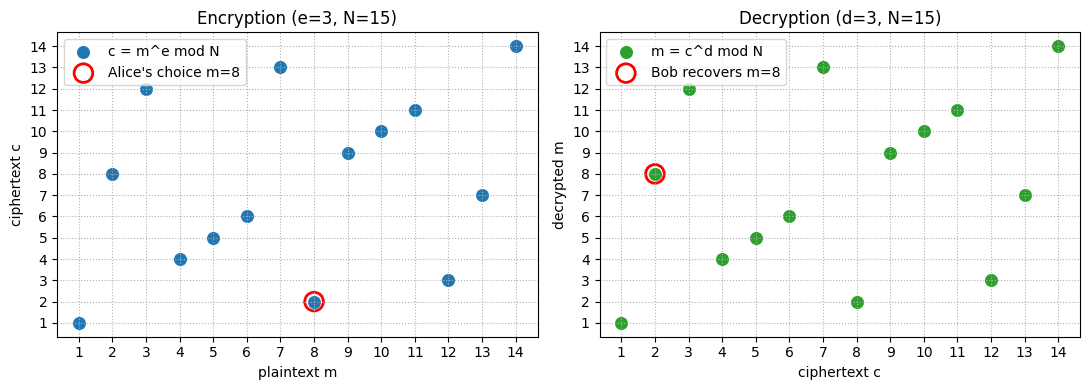

In [6]:
ms = list(range(1, N))
cs = [pow(mi, e, N) for mi in ms]
ds = [pow(ci, d, N) for ci in cs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.scatter(ms, cs, s=70, color='C0', label='c = m^e mod N')
ax1.scatter([m], [c], s=180, facecolors='none', edgecolors='red', linewidths=2, label=f"Alice's choice m={m}")
ax1.set_xlabel('plaintext m'); ax1.set_ylabel('ciphertext c')
ax1.set_title(f'Encryption (e={e}, N={N})')
ax1.set_xticks(ms); ax1.set_yticks(ms); ax1.grid(True, linestyle=':'); ax1.legend()

ax2.scatter(cs, ds, s=70, color='C2', label='m = c^d mod N')
ax2.scatter([c], [m], s=180, facecolors='none', edgecolors='red', linewidths=2, label=f"Bob recovers m={m}")
ax2.set_xlabel('ciphertext c'); ax2.set_ylabel('decrypted m')
ax2.set_title(f'Decryption (d={d}, N={N})')
ax2.set_xticks(ms); ax2.set_yticks(ms); ax2.grid(True, linestyle=':'); ax2.legend()

fig.tight_layout(); plt.show()

## 6. Export the public artifacts for Eve

Eve (Notebooks 2 and 3) only sees what Alice transmits in the clear plus what Bob publishes:

- the public key `(N, e)`
- the ciphertext `c`

Eve never sees `p`, `q`, `phi`, or `d`. These three values are saved to `rsa_public.json` so the next two notebooks can load them. (Those notebooks also include the same hardcoded fallbacks, so they remain runnable standalone.)

In [ ]:
public_blob = {
    'N': int(N),
    'e': int(e),
    'c': int(c),
    # plaintext is included only so the other notebooks can self-check at the end;
    # Eve would NOT have access to this in real life.
    '_plaintext_for_verification_only': int(m),
}

out = Path('rsa_public.json')
out.write_text(json.dumps(public_blob, indent=2))
print(f'wrote {out.resolve()}')
print(json.dumps(public_blob, indent=2))

## Recap

- Bob's hard work happens **once**: pick two primes and publish their product.
- Encryption and decryption are both single modular exponentiations.
- The security of the whole scheme rests on one assumption: *given only `N`, it is computationally infeasible to recover `p` and `q`.* At `N = 15` that assumption is laughable; at `N ≈ 2^2048` it is the bedrock of every TLS handshake on the internet.

Notebook 2 attacks the demonstration classically. Notebook 3 attacks it with Shor's algorithm on an IBM quantum computer.